In [1]:
# mamba activate spatiocore_spatial_env
import os
import re
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import random



warnings.filterwarnings("ignore")
sc.settings.verbosity = 1
%config InlineBackend.figure_format = 'retina'
# ---- Publication-quality style ----------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 100,
    "savefig.bbox": "tight",
    "savefig.transparent": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
sns.set_context("paper")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
adata = sc.read_h5ad(os.path.join(pathout, "andata_nb_orig_metadata.h5ad"))
sc.pp.calculate_qc_metrics(adata, percent_top=None,log1p=False, inplace=True)

In [3]:
SAMPLE_COL = "punch_id"
COUNT_COL = "total_counts"
GENE_COL = "n_genes_by_counts"

MIN_TOTAL_COUNTS = 50
MIN_GENES_BY_COUNTS = 20
MAX_TOTAL_COUNTS_Q = 0.995
MIN_CELLS_PER_GENE = 10

max_total_counts = adata.obs[COUNT_COL].quantile(MAX_TOTAL_COUNTS_Q)

qc_keep = (
    (adata.obs[COUNT_COL] >= MIN_TOTAL_COUNTS) &
    (adata.obs[GENE_COL] >= MIN_GENES_BY_COUNTS) &
    (adata.obs[COUNT_COL] <= max_total_counts)
)
adata_qc = adata[qc_keep].copy()
sc.pp.filter_genes(adata_qc, min_cells=MIN_CELLS_PER_GENE)

In [4]:
adata_qc.layers["raw_counts"] = adata_qc.X.copy()
sc.pp.log1p(adata_qc)
adata_qc.layers["log"] = adata_qc.X.copy()

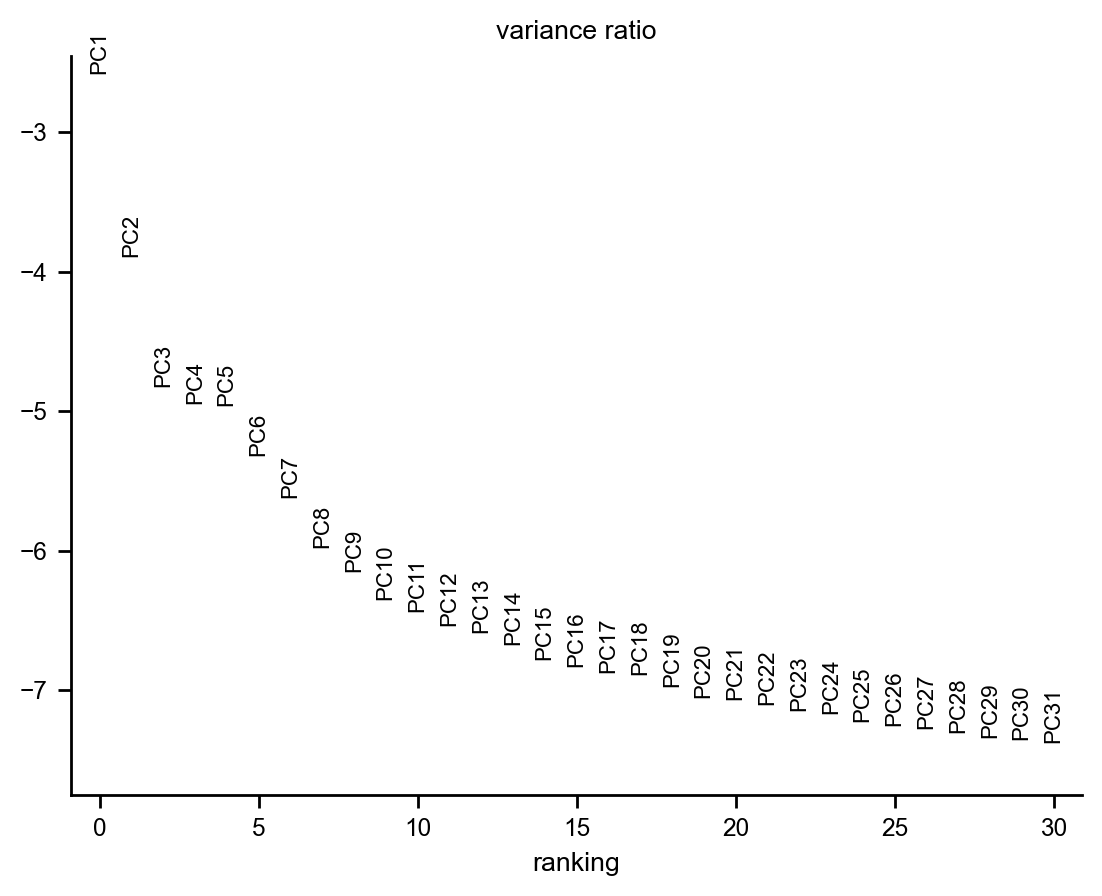

In [5]:
sc.pp.scale(adata_qc, max_value=10)
sc.tl.pca(adata_qc, n_comps=50, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_qc, log=True)

In [6]:
andata_test_para = adata_qc.copy()

In [7]:
andata_test_para.obs['punch_id'].unique()

['21', '26', '1', '16', '6', ..., '28', '31', '36', '41', '46']
Length: 50
Categories (50, object): ['1' < '2' < '3' < '4' ... '47' < '48' < '49' < '50']

In [8]:
# remove liver samples
andata_test_para = andata_test_para[~andata_test_para.obs['punch_id'].isin(['3','5','10'])]

In [9]:
andata_test_para = sc.pp.subsample(andata_test_para, fraction = 0.1, random_state=1980,copy = True)

In [10]:
andata_test_para

AnnData object with n_obs × n_vars = 66926 × 5006
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample_lab', 'mouse_id', 'Condition', 'Type', 'punch_id', 'n_genes_by_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'Condition_colors', 'Type_colors', 'mouse_id_colors', 'punch_id_colors', 'sample_lab_colors', 'spatialdata_attrs', 'log1p', 'pca'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
    layers: 'raw_counts', 'log'

In [11]:
# (10, 20, 30, 40, 50, 60,70,80,90,100),
def test_neighbor_umaps(
    adata,
    neighbor_values=(10, 20, 30, 40, 50, 60),
    use_rep="X_pca",
    n_pcs=20,
    leiden_resolution=1.0,
    random_state=1337,
    point_size=5,
    n_cols=3,
    palette=None,
):
    """
    Test different KNN neighborhood sizes.

    For each n_neighbors value, this function:
    1. Computes neighbors.
    2. Runs Leiden clustering.
    3. Computes UMAP.
    4. Stores the UMAP in adata.obsm.
    5. Plots a publication-style UMAP panel.

    Results are added to:
    - adata.uns[f"{n}neig"]
    - adata.obsp[f"{n}neig_connectivities"]
    - adata.obsp[f"{n}neig_distances"]
    - adata.obs[f"cluster_{n}neig"]
    - adata.obsm[f"X_umap_{n}neig"]
    """

    if palette is None:
        palette = make_cluster_palette()

    for n in neighbor_values:
        neighbors_key = f"{n}neig"
        cluster_key = f"cluster_{n}neig"

        sc.pp.neighbors(
            adata,
            n_neighbors=n,
            n_pcs=n_pcs,
            use_rep=use_rep,
            key_added=neighbors_key,
        )

        sc.tl.leiden(
            adata,
            resolution=leiden_resolution,
            random_state=random_state,
            key_added=cluster_key,
            neighbors_key=neighbors_key,
        )

        sc.tl.umap(
            adata,
            neighbors_key=neighbors_key,
            random_state=random_state,
        )

        adata.obsm[f"X_umap_{neighbors_key}"] = adata.obsm["X_umap"].copy()

    n_panels = len(neighbor_values)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.7 * n_cols, 3.4 * n_rows),
        constrained_layout=True,
    )

    axes = np.array(axes).ravel()

    for ax, n in zip(axes, neighbor_values):
        neighbors_key = f"{n}neig"
        cluster_key = f"cluster_{n}neig"
        basis = f"umap_{neighbors_key}"

        n_clusters = adata.obs[cluster_key].nunique()
        X = adata.obsm[f"X_{basis}"]

        sc.pl.embedding(
            adata,
            basis=basis,
            color=cluster_key,
            ax=ax,
            s=point_size,
            frameon=False,
            show=False,
            title=f"KNN: {n}\n({n_clusters} clusters)",
            palette=palette,
            legend_loc=None,
        )

        ax.set_xlim(X[:, 0].min(), X[:, 0].max())
        ax.set_ylim(X[:, 1].min(), X[:, 1].max())
        ax.set_aspect("equal", adjustable="box")

    for ax in axes[n_panels:]:
        ax.axis("off")

    plt.show()
    
def make_cluster_palette(seed=30):
    palette = (
        sns.color_palette("tab20", 20)
        + sns.color_palette("tab20b", 20)
        + sns.color_palette("tab20c", 20)
        + sns.color_palette("Set2", 8)
    )
    random.Random(seed).shuffle(palette)
    return palette

2026-06-11 14:51:21.035266: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F, in other operations, rebuild TensorFlow with the appropriate compiler flags.


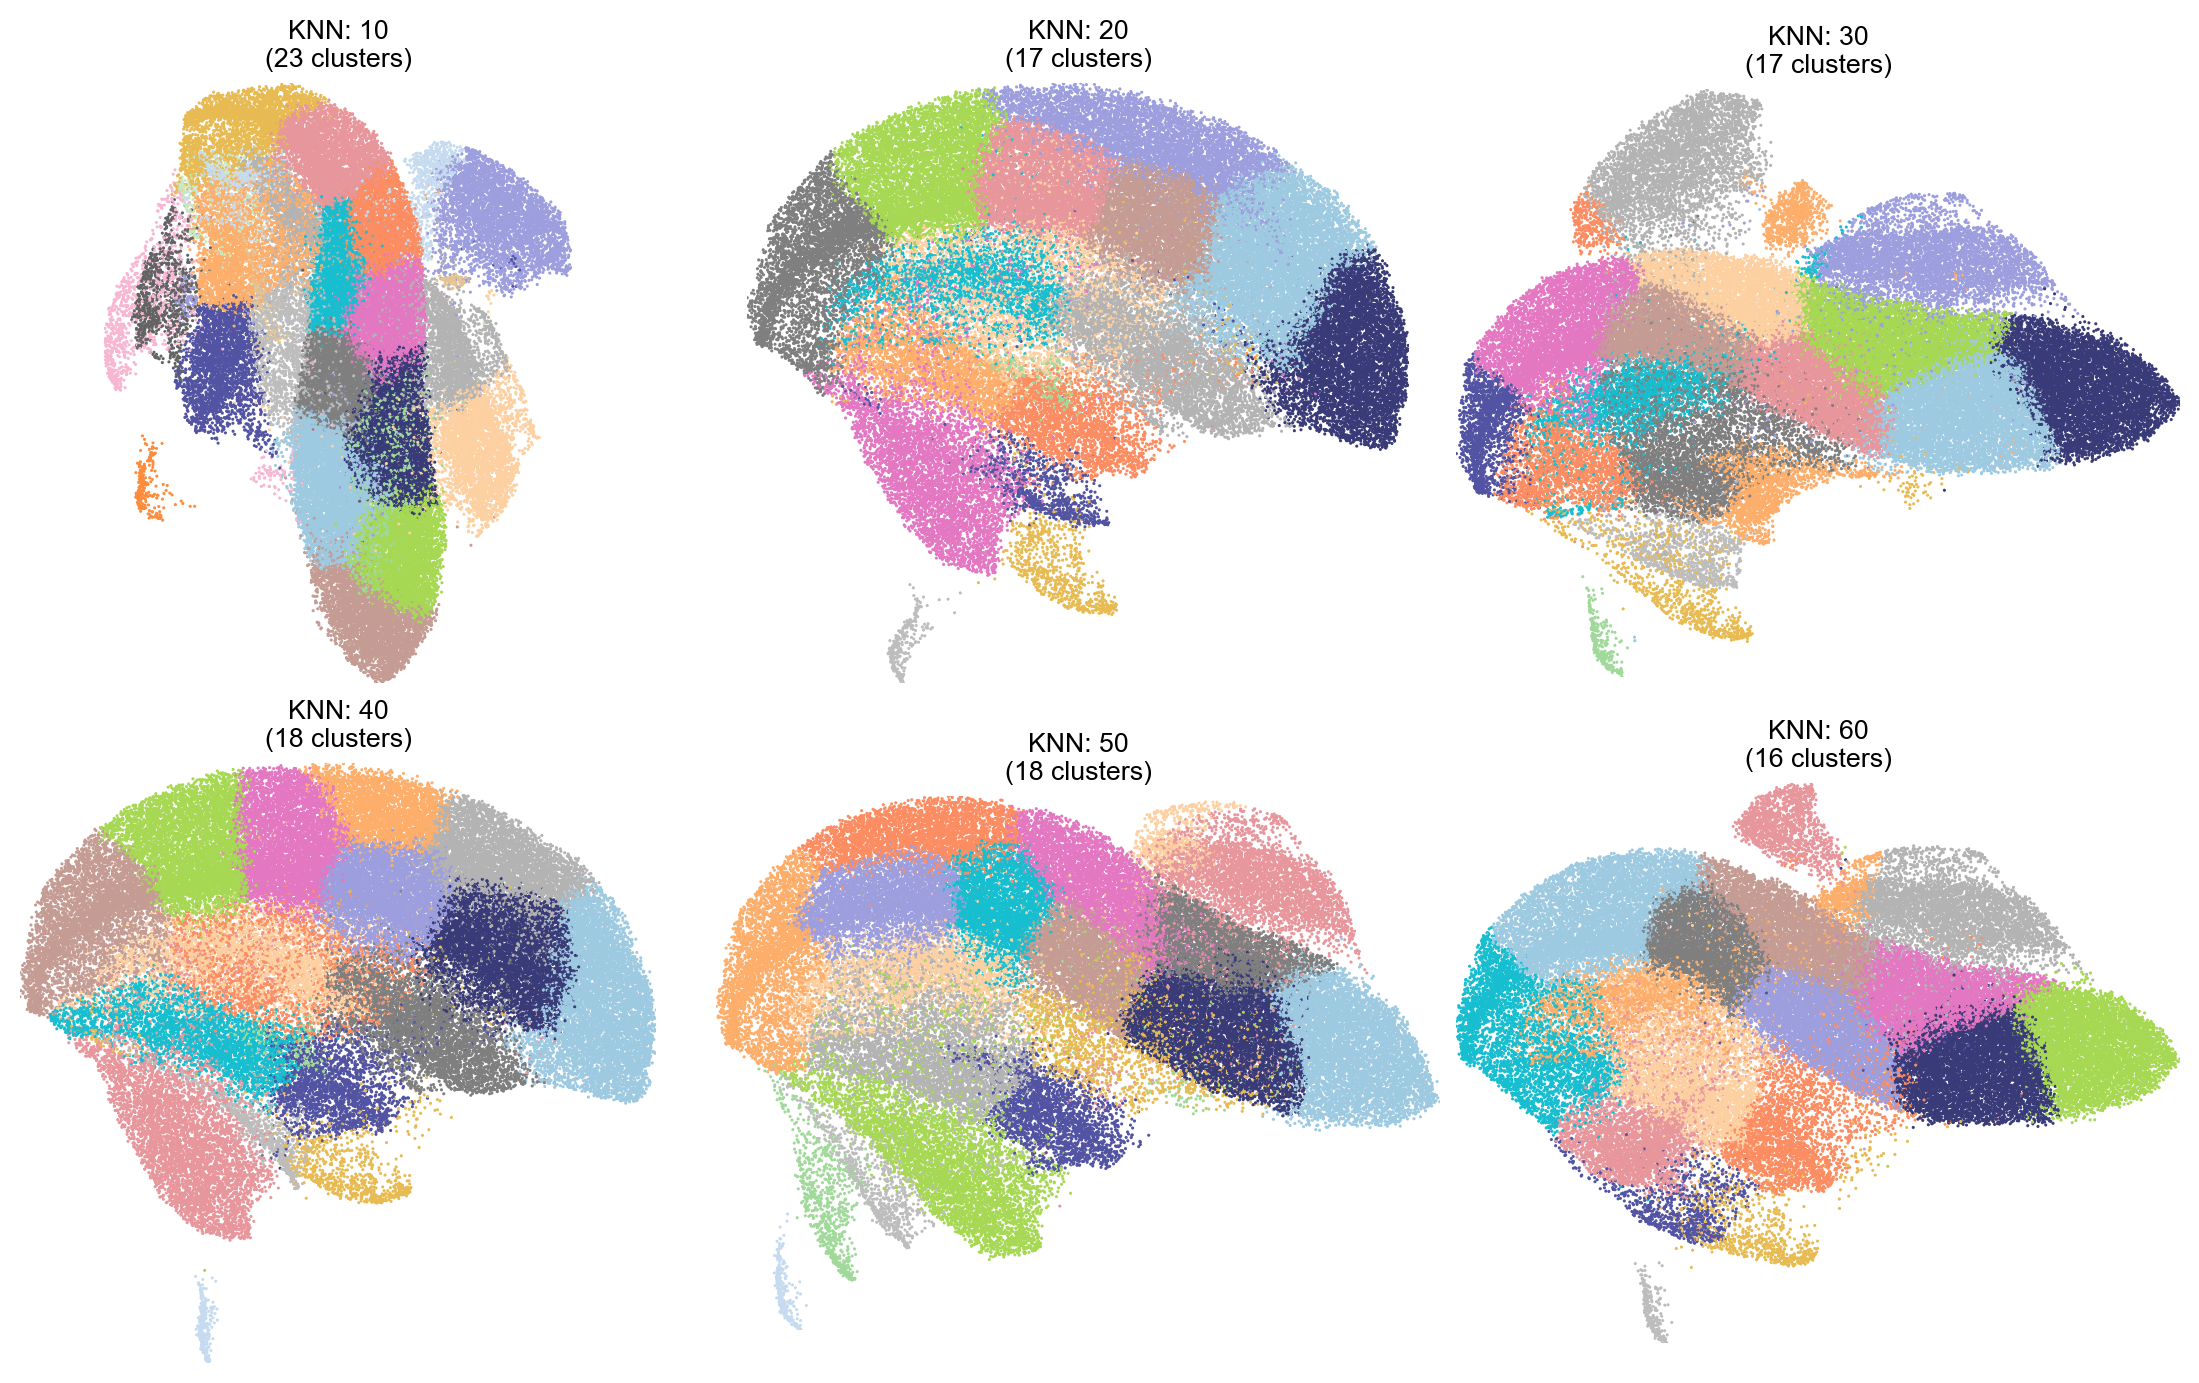

In [12]:
test_neighbor_umaps(
    andata_test_para,
    use_rep="X_pca",
    n_pcs=20,
    leiden_resolution=1.0,
    point_size=5,
)

In [14]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
andata_test_para.write_h5ad(os.path.join(pathout, "andata_subsample.h5ad"))

In [ ]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
andata_test_para.write_h5ad(os.path.join(pathout, "adata_nb_processed.h5ad"))

In [1]:
# mamba activate scib-metrics
import igraph as ig
import scanpy as sc
import igraph as ig
from scib.metrics import isolated_labels_asw, graph_connectivity
import pandas as pd
import os
from tqdm import tqdm 

In [2]:
import h5py
import os

pathout = "/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig"
fn = os.path.join(pathout, "andata_subsample.h5ad")

with h5py.File(fn, "a") as f:
    for key in [
        "uns/log1p/base",
        "uns/pca/params/mask_var",
    ]:
        if key in f:
            del f[key]

andata = sc.read_h5ad(fn)

In [5]:
# load subsample_file
# pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
# andata = sc.read_h5ad(os.path.join(pathout, "andata_subsample.h5ad"))

In [ ]:
neighbors_key = "30neig"

andata.obsp["connectivities"] = andata.obsp[f"{neighbors_key}_connectivities"]
andata.obsp["distances"] = andata.obsp[f"{neighbors_key}_distances"]
andata.uns["neighbors"] = andata.uns[neighbors_key]

g = sc._utils.get_igraph_from_adjacency(
    andata.obsp[f"{neighbors_key}_connectivities"],
    directed=False,
)

resolutions = [0.2, 0.4, 0.6, 0.8, 1.0,1.2,1.4,1.6,1.8,2.0]
scores = []

for res in tqdm(resolutions):
    key = f"cluster_{neighbors_key}_resolution_{res}"

    sc.tl.leiden(
        andata,
        resolution=res,
        random_state=1337,
        key_added=key,
        neighbors_key=neighbors_key,
    )

    labels = pd.Categorical(andata.obs[key]).codes.tolist()
    n_clusters = andata.obs[key].nunique()

    Q = g.modularity(labels, weights=g.es["weight"])

    gc = graph_connectivity(
        andata,
        label_key=key,
    )

    scores.append(
        dict(
            resolution=res,
            modularity=Q,
            graph_conn=gc,
            n_clusters=n_clusters,
        )
    )

df = pd.DataFrame(scores).set_index("resolution")
df

  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_3506593/3021026537.py:18: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(
/data/kanferg/conda/envs/scib-metrics/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/data/kanferg/conda/envs/scib-metrics/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/data/kanferg/conda/envs/scib-metrics/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning

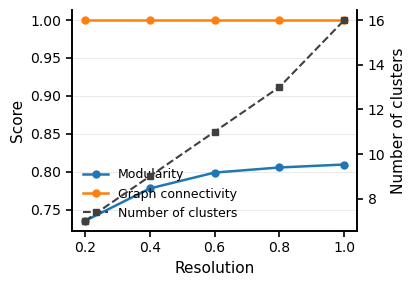

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(4.5, 3.2))

ax1.plot(
    df.index,
    df["modularity"],
    marker="o",
    markersize=5,
    linewidth=1.8,
    color="#1f77b4",
    label="Modularity",
)

ax1.plot(
    df.index,
    df["graph_conn"],
    marker="o",
    markersize=5,
    linewidth=1.8,
    color="#ff7f0e",
    label="Graph connectivity",
)

ax1.set_xlabel("Resolution", fontsize=11)
ax1.set_ylabel("Score", fontsize=11)
ax1.tick_params(axis="both", labelsize=10, width=1.2, length=4)

ax2 = ax1.twinx()
ax2.plot(
    df.index,
    df["n_clusters"],
    marker="s",
    markersize=4.5,
    linewidth=1.5,
    linestyle="--",
    color="0.25",
    label="Number of clusters",
)

ax2.set_ylabel("Number of clusters", fontsize=11)
ax2.tick_params(axis="y", labelsize=10, width=1.2, length=4)

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["right"].set_linewidth(1.2)

ax1.grid(axis="y", linewidth=0.6, alpha=0.3)
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
)

plt.subplots_adjust(bottom=0.28)
plt.show()

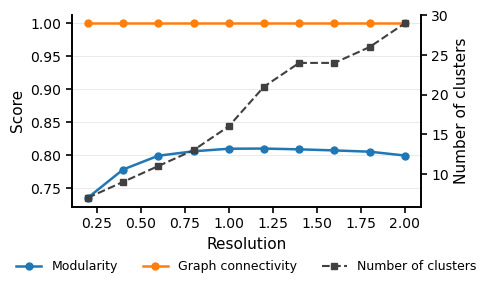

In [20]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(4.5, 3.2))

ax1.plot(
    df.index,
    df["modularity"],
    marker="o",
    markersize=5,
    linewidth=1.8,
    color="#1f77b4",
    label="Modularity",
)

ax1.plot(
    df.index,
    df["graph_conn"],
    marker="o",
    markersize=5,
    linewidth=1.8,
    color="#ff7f0e",
    label="Graph connectivity",
)

ax1.set_xlabel("Resolution", fontsize=11)
ax1.set_ylabel("Score", fontsize=11)
ax1.tick_params(axis="both", labelsize=10, width=1.2, length=4)

ax2 = ax1.twinx()
ax2.plot(
    df.index,
    df["n_clusters"],
    marker="s",
    markersize=4.5,
    linewidth=1.5,
    linestyle="--",
    color="0.25",
    label="Number of clusters",
)

ax2.set_ylabel("Number of clusters", fontsize=11)
ax2.tick_params(axis="y", labelsize=10, width=1.2, length=4)

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["right"].set_linewidth(1.2)

ax1.grid(axis="y", linewidth=0.6, alpha=0.3)
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    fontsize=9,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
)

plt.subplots_adjust(bottom=0.28)
plt.show()

In [ ]:
# mamba activate spatiocore_spatial_env
import os
import re
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import random



warnings.filterwarnings("ignore")
sc.settings.verbosity = 1
%config InlineBackend.figure_format = 'retina'
# ---- Publication-quality style ----------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 100,
    "savefig.bbox": "tight",
    "savefig.transparent": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
sns.set_context("paper")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [ ]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
andata = sc.read_h5ad(os.path.join(pathout, "adata_nb_processed.h5ad"))